<h1> Попытка запустить код из ноутбука <h1>

In [1]:
import tensorflow as tf

# Пример данных
data = tf.constant([10.0, 20.0, 30.0, 40.0, 50.0])

# Min-Max нормализация
min_val = tf.reduce_min(data)
max_val = tf.reduce_max(data)
normalized_data = (data - min_val) / (max_val - min_val)

# Z-score нормализация
mean = tf.reduce_mean(data)
std_dev = tf.math.reduce_std(data)
z_normalized_data = (data - mean) / std_dev
z_normalized_data

<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([-1.4142135 , -0.70710677,  0.        ,  0.70710677,  1.4142135 ],
      dtype=float32)>

In [2]:
categories = tf.constant([0, 1, 2, 3])

one_hot_encoded = tf.keras.utils.to_categorical(categories)
one_hot_encoded

ValueError: Attempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.

In [3]:
import numpy as np

numpy_array = np.array([1, 2, 3, 4, 5])
tensor = tf.convert_to_tensor(numpy_array)
tensor

<tf.Tensor: shape=(5,), dtype=int32, numpy=array([1, 2, 3, 4, 5])>

In [4]:
from sklearn.model_selection import train_test_split

data = tf.random.normal([100, 10])
labels = tf.random.uniform([100], 0, 2, dtype=tf.int32)

# 80% обучение, 10% валидация, 10% тест
train_data, temp_data, train_labels, temp_labels = train_test_split(data, labels, test_size=0.2)
val_data, test_data, val_labels, test_labels = train_test_split(temp_data, temp_labels, test_size=0.5)

TypeError: Only integers, slices (`:`), ellipsis (`...`), tf.newaxis (`None`) and scalar tf.int32/tf.int64 tensors are valid indices, got array([64, 94, 53, 70, 79, 68, 18, 55, 23, 83, 49, 59, 36,  2, 91, 84, 82,
       81, 10, 60, 56, 32, 48, 67, 45, 40, 12, 77, 96, 25, 61, 34, 42, 17,
       63,  8, 76, 16, 72, 13, 80, 65,  3, 99, 31, 98, 43,  7, 78,  1, 54,
       58, 39, 89, 73, 88, 95, 19, 46,  0, 11, 22, 52, 92, 62,  4, 14, 87,
       26, 15, 24, 30, 90,  6, 86, 57, 97, 20, 69, 93])

In [5]:
dataset = tf.data.Dataset.from_tensor_slices((data, labels))
dataset = dataset.shuffle(buffer_size=100).batch(32)
dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 10), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [6]:
sequences = tf.constant([[1, 2, 3], [4, 5], [6]])
padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(sequences, padding='post')
padded_sequences

ValueError: Can't convert non-rectangular Python sequence to Tensor.

In [7]:
import torch

# Пример данных
data = torch.tensor([10.0, 20.0, 30.0, 40.0, 50.0])

# Min-Max нормализация
min_val = torch.min(data)
max_val = torch.max(data)
normalized_data = (data - min_val) / (max_val - min_val)

# Z-score нормализация
mean = torch.mean(data)
std_dev = torch.std(data)
z_normalized_data = (data - mean) / std_dev

OSError: [WinError 126] Не найден указанный модуль. Error loading "C:\Users\vboro\AppData\Roaming\Python\Python311\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [10]:
import numpy as np

# 1. Создание данных
X = np.linspace(0, 10, 100)
Y = 2.5 * X + 7 + np.random.normal(0, 1, size=(100,))

Y

array([ 6.99792724,  6.64327145,  7.32591404,  7.31139326,  6.66106637,
        9.93952962,  8.84055984,  9.01794985,  6.83882183,  8.72331398,
        9.07134535,  9.90989698,  8.75935478,  9.33560511,  7.92092418,
       10.51975396, 10.13040281, 12.14786533, 11.42803612, 11.16398976,
       13.37358469, 12.38413323, 12.48289329, 13.02924336, 13.72354048,
       13.91191688, 13.02396372, 14.43205149, 16.03517589, 16.29342703,
       13.11146395, 14.74803682, 15.72354218, 15.74238954, 16.31419964,
       17.01057075, 17.44186437, 15.45694727, 15.47804982, 16.71448067,
       17.47705663, 17.54772428, 17.2884897 , 17.06098261, 17.20939234,
       18.53897091, 19.4777159 , 17.1256573 , 17.61323179, 19.24432479,
       20.49980411, 20.81329167, 20.83355817, 20.52524457, 19.95183076,
       22.25669025, 21.17581852, 21.03435947, 21.31736602, 21.02453953,
       22.9941374 , 23.48693556, 21.73220384, 20.60796242, 22.37480459,
       24.02384984, 23.83958439, 24.25942351, 24.53968163, 25.49

In [12]:
# 2. Определение модели
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.zeros([1]))
learning_rate = 0.01

b

<tf.Variable 'Variable:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>

In [15]:
# 3. Функция потерь
def compute_loss():
    y_pred = w * X + b
    loss = tf.reduce_mean((Y - y_pred) ** 2)
    return loss

# 4. Обучение модели
for step in range(1000):
    with tf.GradientTape() as tape:
        loss = compute_loss()
    gradients = tape.gradient(loss, [w, b])
    w.assign_sub(learning_rate * gradients[0])
    b.assign_sub(learning_rate * gradients[1])
    if step % 100 == 0:
        print(f"Step: {step}, Loss: {loss.numpy()}")
        print(gradients)

# 5. Результаты
print(f"w = {w.numpy()}, b = {b.numpy()}")

Step: 0, Loss: 0.9762691259384155
[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([2.233684e-05], dtype=float32)>, <tf.Tensor: shape=(1,), dtype=float32, numpy=array([-0.0001443], dtype=float32)>]
Step: 100, Loss: 0.9762693047523499
[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.5571713e-05], dtype=float32)>, <tf.Tensor: shape=(1,), dtype=float32, numpy=array([-8.79094e-05], dtype=float32)>]
Step: 200, Loss: 0.9762691259384155
[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([8.940697e-06], dtype=float32)>, <tf.Tensor: shape=(1,), dtype=float32, numpy=array([-5.593151e-05], dtype=float32)>]
Step: 300, Loss: 0.9762690663337708
[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([5.2154064e-06], dtype=float32)>, <tf.Tensor: shape=(1,), dtype=float32, numpy=array([-3.2324344e-05], dtype=float32)>]
Step: 400, Loss: 0.9762691259384155
[<tf.Tensor: shape=(1,), dtype=float32, numpy=array([9.909272e-06], dtype=float32)>, <tf.Tensor: shape=(1,), dtype=float32, numpy=array([-2.335

<h1> Классификация mnist <h1>

In [39]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [40]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [41]:
train_images.shape

(60000, 28, 28)

In [42]:
len(train_labels)

60000

In [43]:
test_images.shape

(10000, 28, 28)

In [44]:
len(test_labels)

10000

In [45]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

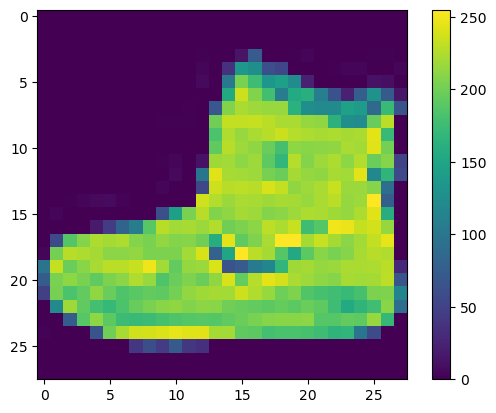

In [46]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.show()

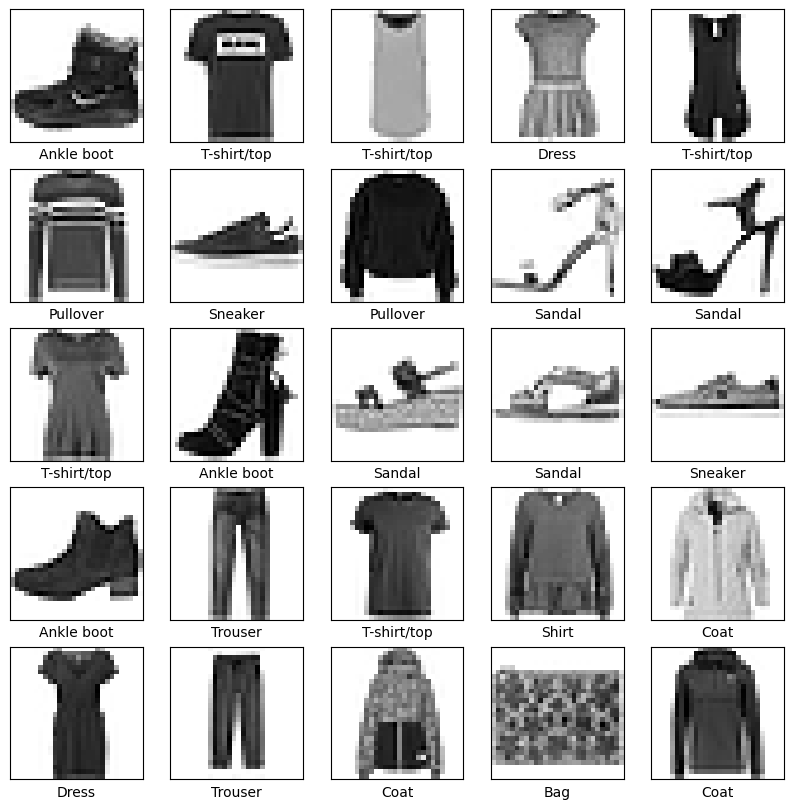

In [47]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [48]:
#масштабирование (снижение значения каждого пикселя(?) на 255)
train_images = train_images / 255.0

test_images = test_images / 255.0

In [49]:
train_images[1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.00392157, 0.        , 0.        , 0.        , 0.        ,
        0.16078431, 0.7372549 , 0.40392157, 0.21176471, 0.18823529,
        0.16862745, 0.34117647, 0.65882353, 0.52156863, 0.0627451 ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.00392157, 0.        ,
        0.        , 0.        , 0.19215686, 0.53333333, 0.85882353,
        0.84705882, 0.89411765, 0.9254902 , 1.        , 1.        ,
        1.        , 1.        , 0.85098039, 0.84313725, 0.99607843,
        0.90588235, 0.62745098, 0.17647059, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.05490196, 0.69019608, 0.87058824, 0.87843137, 0.83137255,
        0.79607843, 0.77647059, 0.76862745, 0.78431373, 0.84313725,
        0.8       , 0.7921

In [51]:
from tensorflow.keras import layers, models, optimizers, losses
model = models.Sequential()
model.add(layers.Flatten(input_shape=(28, 28, 1))) # 28 на 28 - размер изображения, 1 - количество цветов (то есть между белым и черным)
model.add(layers.Dense(500, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

C:\Users\vboro\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
model.compile(optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss=losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# в чем отличие от оптимайзера adam?

In [56]:
model.fit(train_images, train_labels, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.8915 - loss: 0.2935
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - accuracy: 0.8942 - loss: 0.2819
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.8997 - loss: 0.2691
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.9053 - loss: 0.2593
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.9089 - loss: 0.2489


In [57]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Accuracy on the test set: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - accuracy: 0.8798 - loss: 0.3446
Accuracy on the test set: 87.88%


<h1> попробуем увеличить количество эпох <h1>

In [58]:
model.fit(train_images, train_labels, epochs=10, batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.9126 - loss: 0.2358
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.9155 - loss: 0.2325
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 742us/step - accuracy: 0.9181 - loss: 0.2236
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.9210 - loss: 0.2129
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - accuracy: 0.9235 - loss: 0.2093
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 819us/step - accuracy: 0.9259 - loss: 0.2018
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.9265 - loss: 0.1957
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step - accuracy: 0.9284 - loss: 0.1918
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 753us/step - accuracy: 0.9300 - loss: 0.1894
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 754us/step - accuracy: 0.9329 - loss: 0.1825


In [59]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Accuracy on the test set: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - accuracy: 0.8898 - loss: 0.3288
Accuracy on the test set: 88.96%


<h1> Вывод с TensorBoard <h1>

In [75]:
from tensorflow.keras.callbacks import TensorBoard
import datetime

In [76]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [77]:
model.compile(optimizer=optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss=losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [78]:
model.fit(train_images, train_labels, epochs=10, batch_size=128,
          validation_data=(test_images, test_labels),
          callbacks=[tensorboard_callback])

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9583 - loss: 0.1203 - val_accuracy: 0.8971 - val_loss: 0.3112
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9590 - loss: 0.1201 - val_accuracy: 0.8987 - val_loss: 0.3119
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9619 - loss: 0.1123 - val_accuracy: 0.8993 - val_loss: 0.3109
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9608 - loss: 0.1151 - val_accuracy: 0.9011 - val_loss: 0.3074
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9612 - loss: 0.1119 - val_accuracy: 0.8980 - val_loss: 0.3114
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9630 - loss: 0.1106 - val_accuracy: 0.8989 - val_loss: 0.3116
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9649 - loss: 0.1057 - val_accuracy: 0.8958 - val_loss: 0.3112
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9659 - loss: 0.1046 - val_accuracy: 0.

In [79]:
%tensorboard --logdir logs/fit

<h1> Регрессия <h1>

In [95]:
import pandas as pd
df = pd.read_csv("laptop_price.csv", encoding="unicode_escape")

In [97]:
df # Laptop Company Price List for Regression

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1316,Lenovo,Yoga 500-14ISK,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,638.00
1299,1317,Lenovo,Yoga 900-13ISK,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,1499.00
1300,1318,Lenovo,IdeaPad 100S-14IBR,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,229.00
1301,1319,HP,15-AC110nv (i7-6500U/6GB/1TB/Radeon,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,764.00


In [98]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [99]:
df.shape

(1303, 13)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [101]:
df.drop("laptop_ID",axis=1, inplace=True)

In [102]:
df.drop("Product", axis = 1, inplace=True)

In [103]:
df["Weight"] = df["Weight"].str.replace("kg","").astype(float)

In [104]:
df["Weight"].head(5)

0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: Weight, dtype: float64

In [106]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()
cols_to_standardize = ["Inches", "Weight"]
for col in cols_to_standardize:
    df[col] = minmax.fit_transform(df[[col]])

In [107]:
df[cols_to_standardize].head(3)

,Inches,Weight
0,0.385542,0.169576
1,0.385542,0.162095
2,0.662651,0.291771


In [108]:
df = pd.get_dummies(data=df, columns = ["Company"], drop_first=True)

In [109]:
df

,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,...,Company_LG,Company_Lenovo,Company_MSI,Company_Mediacom,Company_Microsoft,Company_Razer,Company_Samsung,Company_Toshiba,Company_Vero,Company_Xiaomi
0,Ultrabook,0.385542,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,0.169576,1339.69,...,False,False,False,False,False,False,False,False,False,False
1,Ultrabook,0.385542,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,0.162095,898.94,...,False,False,False,False,False,False,False,False,False,False
2,Notebook,0.662651,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,0.291771,575.00,...,False,False,False,False,False,False,False,False,False,False
3,Ultrabook,0.638554,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,0.284289,2537.45,...,False,False,False,False,False,False,False,False,False,False
4,Ultrabook,0.385542,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,0.169576,1803.60,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,2 in 1 Convertible,0.469880,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,0.276808,638.00,...,False,True,False,False,False,False,False,False,False,False
1299,2 in 1 Convertible,0.385542,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,0.152120,1499.00,...,False,True,False,False,False,False,False,False,False,False
1300,Notebook,0.469880,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,0.201995,229.00,...,False,True,False,False,False,False,False,False,False,False
1301,Notebook,0.662651,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,0.374065,764.00,...,False,False,False,False,False,False,False,False,False,False


In [111]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ['TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu',
       'OpSys']
for col in cols:
    df[col] = le.fit_transform(df[col])
df.head()

,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros,...,Company_LG,Company_Lenovo,Company_MSI,Company_Mediacom,Company_Microsoft,Company_Razer,Company_Samsung,Company_Toshiba,Company_Vero,Company_Xiaomi
0,4,0.385542,23,65,8,4,58,8,0.169576,1339.69,...,False,False,False,False,False,False,False,False,False,False
1,4,0.385542,1,63,8,2,51,8,0.162095,898.94,...,False,False,False,False,False,False,False,False,False,False
2,3,0.662651,8,74,8,16,53,4,0.291771,575.00,...,False,False,False,False,False,False,False,False,False,False
3,4,0.638554,25,85,1,29,9,8,0.284289,2537.45,...,False,False,False,False,False,False,False,False,False,False
4,4,0.385542,23,67,8,16,59,8,0.169576,1803.60,...,False,False,False,False,False,False,False,False,False,False


In [133]:
X = tf.constant(df.loc[:, df.columns != 'Price_euros'], dtype = tf.float32, name = "features")
y = tf.constant(df["Price_euros"], dtype = tf.float32, name = "target")

In [165]:
n_epoch = 10000
learning_rate = 0.000001
m, n = df.shape
n = n-1

In [163]:
theta = tf.Variable(tf.random.uniform([n, 1], -1.0, 1.0), name = "theta")
theta

<tf.Variable 'theta:0' shape=(27, 1) dtype=float32, numpy=
array([[ 0.7803824 ],
       [ 0.34148407],
       [ 0.11324048],
       [-0.6631179 ],
       [ 0.2285111 ],
       [-0.24492979],
       [-0.6190584 ],
       [-0.76140404],
       [-0.21225524],
       [ 0.14729548],
       [-0.8807652 ],
       [-0.05753255],
       [-0.8691189 ],
       [ 0.31060123],
       [-0.04260707],
       [ 0.99444556],
       [-0.8758526 ],
       [ 0.15491486],
       [ 0.4659207 ],
       [ 0.91064334],
       [-0.38031316],
       [-0.87431073],
       [-0.27738643],
       [ 0.86912775],
       [-0.9882536 ],
       [-0.53179216],
       [ 0.5386472 ]], dtype=float32)>

In [166]:

for epoch in range(n_epoch):
   y_pred = tf.matmul(X, theta, name = "predictions")
   error = y_pred - y
   mse = tf.reduce_mean(tf.square(error), name = "mse")
   gradients = 2/m * tf.matmul(tf.transpose(X), error)
   theta = theta - learning_rate * gradients
  
   if epoch % 100 == 0:
      print("Epoch: ", epoch, "MSE: ", mse)

# 5. Результаты
#print(f"w = {w.numpy()}, b = {b.numpy()}")


Epoch:  0 MSE:  tf.Tensor(126438.85, shape=(), dtype=float32)
Epoch:  100 MSE:  tf.Tensor(125341.32, shape=(), dtype=float32)
Epoch:  200 MSE:  tf.Tensor(124275.31, shape=(), dtype=float32)
Epoch:  300 MSE:  tf.Tensor(123239.79, shape=(), dtype=float32)
Epoch:  400 MSE:  tf.Tensor(122233.65, shape=(), dtype=float32)
Epoch:  500 MSE:  tf.Tensor(121255.96, shape=(), dtype=float32)
Epoch:  600 MSE:  tf.Tensor(120305.71, shape=(), dtype=float32)
Epoch:  700 MSE:  tf.Tensor(119381.945, shape=(), dtype=float32)
Epoch:  800 MSE:  tf.Tensor(118483.81, shape=(), dtype=float32)
Epoch:  900 MSE:  tf.Tensor(117610.414, shape=(), dtype=float32)
Epoch:  1000 MSE:  tf.Tensor(116760.91, shape=(), dtype=float32)
Epoch:  1100 MSE:  tf.Tensor(115934.52, shape=(), dtype=float32)
Epoch:  1200 MSE:  tf.Tensor(115130.445, shape=(), dtype=float32)
Epoch:  1300 MSE:  tf.Tensor(114347.93, shape=(), dtype=float32)
Epoch:  1400 MSE:  tf.Tensor(113586.25, shape=(), dtype=float32)
Epoch:  1500 MSE:  tf.Tensor(11284

In [ ]:
<h1> При подборе значений лучший результат получился при тех значениях, что выше. К